# Beyond BLAST

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [2]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/new_funcs.jl");

In [3]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using .Blast
using .blast_tutorials;

### Computing background quantities:

redshift $z$, comoving distance $\chi(z)$

In [250]:
# i want to save in a .txt file called "dimensions.txt" the size of all the arrays unsigned
# name of the file is "dimensions.txt"

In [251]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
χ_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

### Saving array dimensions in "dimensions.txt"

In [282]:
open("dimensions.txt", "w") do f
    write(f, "------------------------ \n")
    write(f, "IMPORTED REDSHIFT\n")
    write(f, "Redshift array z_b taken from background has dimensions: $(size(z_b))\n")
    write(f, "MIN = $(minimum(z_b)) || MAX = $(maximum(z_b)) \n")
    write(f, "------------------------ \n")
    write(f, "IMPORTED COMOVING DISTANCE\n")
    write(f, "Comoving distance array χ_b taken from background has dimensions: $(size(χ_b))\n")
    write(f, "MIN = $(minimum(χ_b)) || MAX = $(maximum(χ_b)) \n")
    write(f, "------------------------ \n")
    write(f, "INTERPOLATED QUANTITIES\n")
    write(f, "Redshift interpolated array z_of_χ has dimensions: $(size(z_of_χ(χ_b)))\n")
    write(f, "MIN = $(minimum(z_of_χ(χ_b))) || MAX = $(maximum(z_of_χ(χ_b))) \n")
    write(f, "Comoving distance interpolated array χ_of_z has dimensions: $(size(χ_of_z(z_b)))\n")
    write(f, "MIN = $(minimum(χ_of_z(z_b))) || MAX = $(maximum(χ_of_z(z_b))) \n")
    write(f, "------------------------ \n")
    write(f, "z_b = z_of_χ(χ_b) and x_b = χ_of_z(z_b), up to numerical precision.\n")
    write(f, "------------------------ \n")
end;

In [283]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
z_n5k = sort(z_n5k) # sort the redshift array in ascending order
n_z_matrix = n5k_bins["dNdz_cl"];

In [284]:
open("dimensions.txt", "a") do f
    write(f, "N5K QUANTITIES\n")
    write(f, "n5k_bins has columns: $(keys(n5k_bins))\n")
    write(f, "------------------------ \n")
    write(f, "dN/dz\n")
    write(f, "numerical density N5K dN/dz (for clustering) has dimensions: $(size(n5k_bins["dNdz_cl"]))\n")
    write(f, "MIN = $(minimum(n_z_matrix)) || MAX = $(maximum(n_z_matrix)) \n")
    write(f, "------------------------ \n")
    write(f, "REDSHIFT z\n")
    write(f, "redshift N5K z (for clustering) has dimensions: $(size(n5k_bins["z_cl"]))\n")
    write(f, "MIN = $(minimum(n5k_bins["z_cl"])) || MAX = $(maximum(n5k_bins["z_cl"])) \n")
    write(f, "------------------------ \n")
    write(f, "There are $(size(n5k_bins["z_cl"])[1]) redshift values for each of the $(size(n5k_bins["dNdz_cl"])[2]) bins.\n")
    write(f, "------------------------ \n")
end;

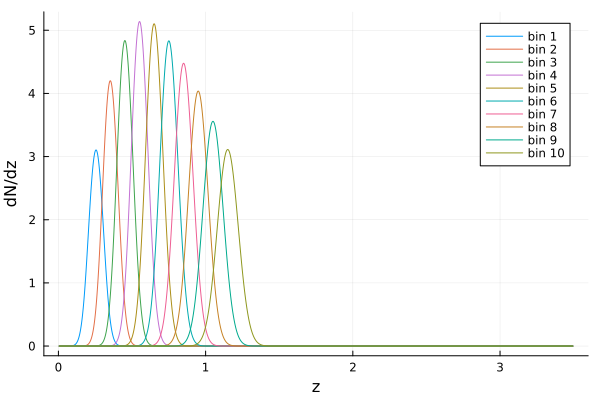

In [285]:
p = plot()
for i in 1:size(n_z_matrix, 2)
    plot!(p, z_n5k, n_z_matrix[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
display(p)

### Normalizing n(z)

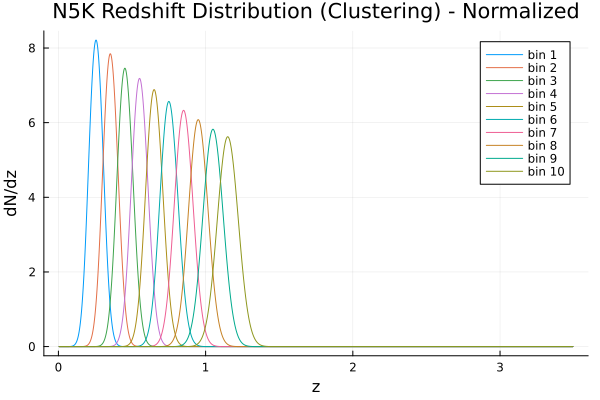

In [286]:
norms = [quadgk(x -> DataInterpolations.AkimaInterpolation(n_z_matrix[:, i], z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                minimum(z_n5k), maximum(z_n5k))[1] for i in 1:size(n_z_matrix, 2)]
n_z_norm = n_z_matrix ./ reshape(norms, 1, :);
#### PLOTTING the results
p = plot()
for i in 1:size(n_z_norm, 2)
    plot!(p, z_n5k, n_z_norm[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
title!(p, "N5K Redshift Distribution (Clustering) - Normalized")
display(p)

In [287]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "N5K dN/dz normalization\n")
    write(f, "The N5K dN/dz values for each bin are normalized such that the integral over redshift is 1.\n")
    write(f, "The norms used for normalization are: \n$(norms)\n")
    write(f, "------------------------ \n")
    write(f, "The normalized N5K dN/dz values for each bin have dimensions: \n$(size(n_z_norm))\n")
    write(f, "MIN = $(minimum(n_z_norm)) || MAX = $(maximum(n_z_norm)) \n")
end;

In [288]:
#### REDSHIFT ARRAY
z_array = LinRange(minimum(z_n5k), maximum(z_n5k), size(z_n5k)[1]) # array of redshifts to evaluate n(z) on
#### COMOVING DISTANCES ARRAY
chi_array = χ_of_z.(z_array); # array of comoving distances corresponding to z_range

In [289]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "REDSHIFT ARRAY\n")
    write(f, "Redshift z_array is a vector or dimension: $(size(z_array))\n")
    write(f, "MIN = $(minimum(z_array)) || MAX = $(maximum(z_array))\n")
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCE ARRAY\n")
    write(f, "Comoving distance chi_array is a vector or dimension: $(size(chi_array))\n")
    write(f, "MIN = $(minimum(chi_array)) || MAX = $(maximum(chi_array))\n")
    write(f, "------------------------ \n")
    write(f, "Values of normalized N5K dN/dz (clustering) for the first bin are: \n$(n_z_norm[:, 1])\n")
    write(f, "------------------------ \n")
end;

In [290]:
cosmo = Blast.FlatΛCDM()
n_chi = 96;                  # Number of comoving distance points

In [291]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS: $nχ\n")
end;

In [292]:
# Array of comoving distances
x_array = LinRange(26, 7000, nχ)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(x_array);

In [293]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCES AND CORRESPONDING REDSHIFTS\n")
    write(f, "Array of comoving distances x_array has dimensions: $(size(x_array))\n")
    write(f, "MIN = $(minimum(x_array)) || MAX = $(maximum(x_array)) \n")
    write(f, "Array of redshifts z_range has dimensions: $(size(z_range))\n")
    write(f, "MIN = $(minimum(z_range)) || MAX = $(maximum(z_range)) \n")
    write(f, "------------------------ \n")
end;

In [294]:
###### BIAS ######
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = b_0 .* sqrt.(1 .+ z_range); # bias as a function of redshift

In [295]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

In [296]:
###### GROWTH FACTOR ######
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_range)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_range]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_range);

In [297]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "GROWTH FACTOR ARRAY\n")
    write(f, "Array of growth factor values D_z_array has dimensions: $(size(growth_array))\n")
    write(f, "MIN = $(minimum(growth_array)) || MAX = $(maximum(growth_array)) \n")
  end;

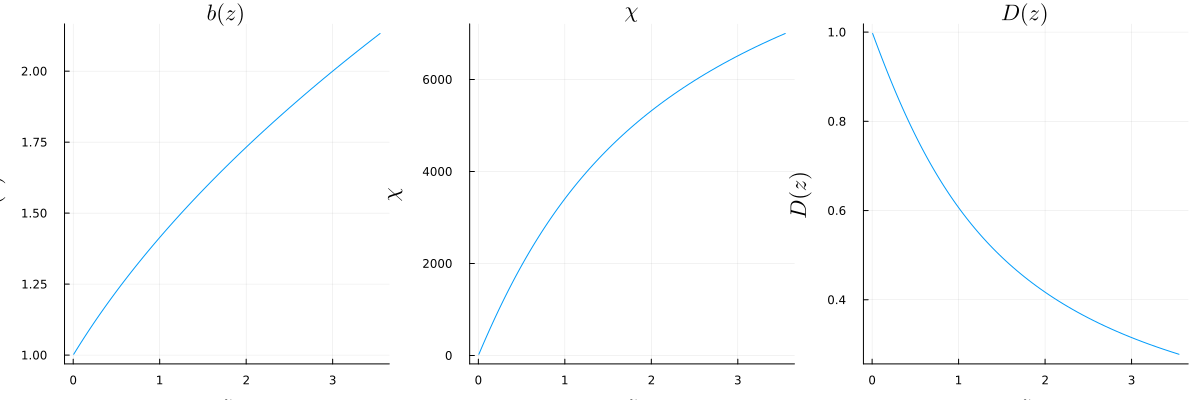

In [298]:
p1 = plot(z_range, 
          b_z_array, 
          label=L"$b(z)$", 
          xlabel=L"$z$", 
          ylabel=L"$b(z)$", 
          title=L"$b(z)$")
p2 = plot(z_range, 
          x_array, 
          label=L"z and $\chi$",
          title = L"$\chi$",
          xlabel=L"$z$", 
          ylabel=L"$\chi$")
p3 = plot(z_range, 
          growth_array, 
          label="Growth Factor D(z)", 
          xlabel=L"$z$", 
          ylabel=L"$D(z)$", 
          title=L"$D(z)$")
plot(p1, p2, p3, layout=(1,3), titlefontsize=15, labelfontsize=15, legendfontsize=15, size=(1200,400), legend=false)


In [299]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Array of redshifts: z_range has dimensions: $(size(z_range)) || z_array has dimensions: $(size(z_array))\n")
  end;

In [300]:
n_bins = size(n_z_norm, 2) # number of tomographic bins
nz = zeros(n_chi, n_bins) # size nx per number of bins
for b in 1:n_bins
     nz_func = DataInterpolations.AkimaInterpolation(n_z_norm[:, b], z_array, extrapolation=ExtrapolationType.Linear)
     nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
     #println("Bin $b: Normalized n(z) integral: ", nz_norm)
     nz[:, b] = nz_func.(z_range)
     #println("Bin $b: n(z) has size: ", size(nz))
end

In [301]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
  end;

In [302]:
prefac = x_array.^2 .* b_z_array .* growth_array
kernel_composed = reshape(prefac, :, 1) .* nz;

In [303]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
    write(f, "Size of prefactor array (chi^2 * b(z) * D(z)): $(size(prefac))\n")
    write(f, "Size of kernel_composed array: $(size(kernel_composed))\n")
    write(f, "The prefactor array is the product of chi^2, b(z), and D(z) evaluated at the redshifts corresponding to the comoving distances in x_array.\n")
    write(f, "Size of array z_range: $(size(z_range))\n")
    write(f, "Size of array x_array: $(size(x_array))\n")
    write(f, "Size of array b_z_array: $(size(b_z_array))\n")
    write(f, "Size of array growth_array: $(size(growth_array))\n")
    write(f, "Size of array nz: $(size(nz))\n")
  end;

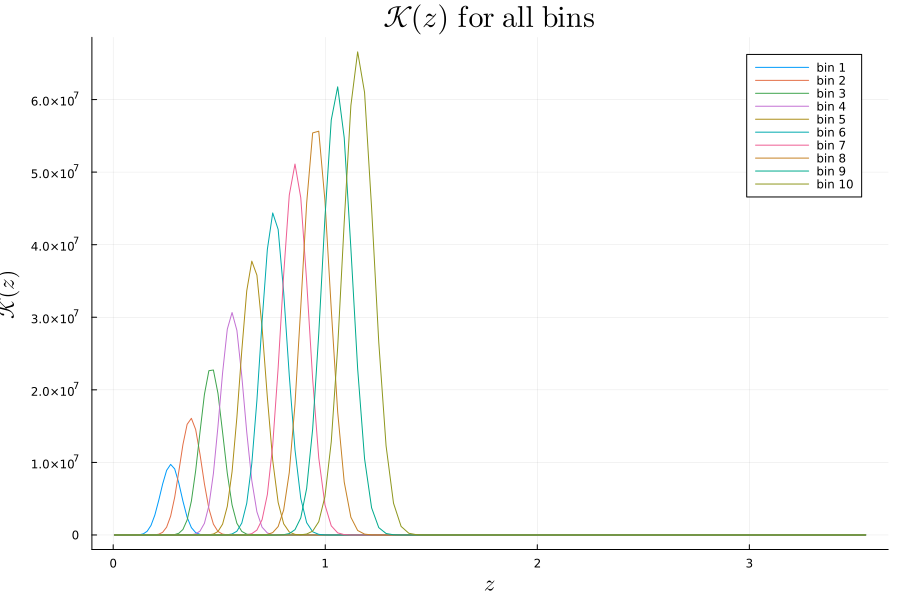

In [304]:
p = plot(
    xlabel=L"$z$",
    ylabel=L"\mathcal{K}(z)",
    title=L"\mathcal{K}(z)\ \mathrm{for\ all\ bins}",
    xlabelfontsize=15,
    ylabelfontsize=15,
    titlefontsize=20,
    legendfontsize=8,
    size=(900, 600)
)
for b in 1:size(kernel_composed, 2)
    plot!(p, z_range, kernel_composed[:, b], label="bin $b")
end
display(p)

In [305]:
ℓ = Blast.ℓ
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
χ = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
R = chebpoints(n_chi, -1, 1)                          # array of ratios between comoving distances
R = reverse(R[R.>0])
nR = length(R)                                        # number of ratios R
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^(15)+1;                                         # number of integration points

# Define k' and k'' on Chebyshev grid
#k1 = k2 = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)) # wavenumbers k' and k''

In [306]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "INPUT PARAMETERS")
    write(f, "MIN COMOVING DISTANCE = $x_min, MAX COMOVING DISTANCE = $x_max, \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS = $n_chi, \n")
    write(f, "NUMBER OF RATIOS R = $nR, \n")
    write(f, "MIN RATIO Rmin = $(minimum(R)), MAX RATIO Rmax = $(maximum(R)), \n")
    write(f, "MIN WAVENUMBER kmin = $kmin, MAX WAVENUMBER kmax = $kmax, \n")
    write(f, "NUMBER OF CHEBYSHEV NODES = $n_cheb, \n")
    write(f, "NUMBER OF INTEGRATION POINTS = $N, \n")
    write(f, "EXPONENT β = -2 for shear-shear, 0 for galaxy-shear and 2 for galaxy-galaxy \n")
  end;

In [307]:
# I choose a grid of Chebyshev nodes in z, which I will use to evaluate 
# the kernels and the power spectrum.
zmin = first(z_range)
zmax = last(z_range)

t_of_z(z) = (2*z - (zmax + zmin)) / (zmax - zmin)
z_of_t(t) = (zmin + zmax)/2 + (zmax - zmin)/2 * t

j = 1:n_cheb
t_nodes = cos.((2 .* j .- 1) .* pi ./ (2*n_cheb))     # size N, in [-1,1]
z_nodes = z_of_t.(t_nodes);                            # Chebyshev nodes in z

In [308]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "REDSHIFT GRID")
    write(f, "MIN REDSHIFT = $zmin, MAX REDSHIFT = $zmax, \n")
    write(f, "Dimension of z_nodes = $n_cheb \n")
    write(f, "Dimension of t_nodes = $n_cheb \n")
    write(f, "MIN Chebyshev node in z: $(z_nodes[1]), MAX Chebyshev node in z: $(z_nodes[end]) \n")
    write(f, "MIN Chebyshev node in t: $(t_nodes[1]), MAX Chebyshev node in t: $(t_nodes[end]) \n")
  end;

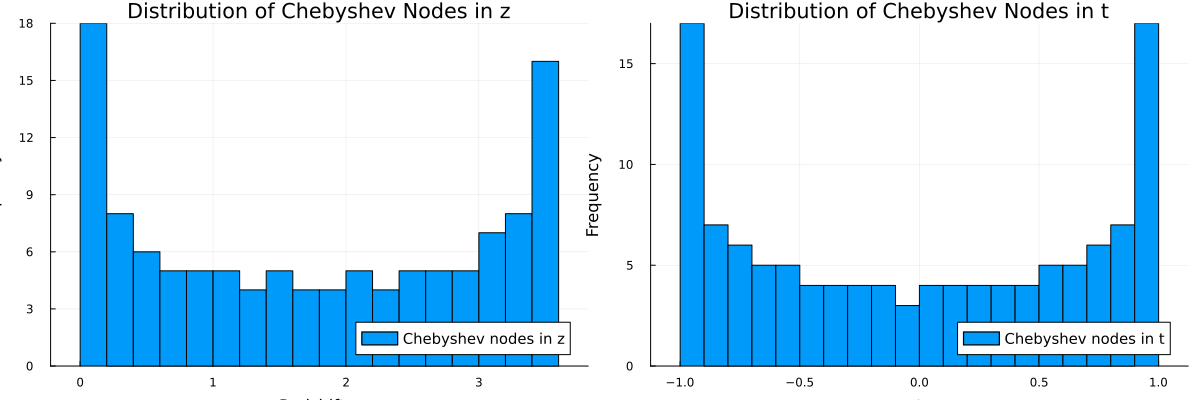

In [309]:
h1 = histogram(z_nodes, bins=20, 
               label="Chebyshev nodes in z", 
               xlabel="Redshift z", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in z",
               legendfontsize=10,
               legend=:bottomright)
h2 = histogram(t_nodes, bins=20, 
               label="Chebyshev nodes in t", 
               xlabel="t", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in t",
               legendfontsize=10,
               legend=:bottomright)
plot(h1, h2, layout=(1,2), size=(1200,400))